# Galaxy Zoo 2 Study

WOR vs. Cross-PPI (Zrnic & Candès), Bernoulli active inference, and classical estimation
on Galaxy Zoo 2. Single population (overall spiral fraction), 1000 seeds, 20 budgets (1%-20%).

Active inference is still pending, so it does not appear below yet. Once its results are in
`results/`, re-running this notebook picks it up automatically.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import glob

TICK_SIZE, SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE = 6, 6, 8, 11
MARKERSIZE, LINEWIDTH = 3, 0.5
plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=TICK_SIZE)
plt.rc("ytick", labelsize=TICK_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("lines", markersize=MARKERSIZE, linewidth=LINEWIDTH)
plt.rc("grid", linewidth=0.5, alpha=0.5)

colors = ["#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628",
          "#984ea3", "#999999", "#e41a1c", "#dede00"]

## Data overview

In [9]:
Y = np.load("data/Y.npy").flatten()
Yhat = np.load("data/Yhat.npy").flatten()
N = len(Y)
N_GROUP = {"all": N}

print(f"N = {N:,} galaxies")
print(f"Spiral fraction (theta*) = {Y.mean():.4f}")
print(f"Mean prediction Yhat     = {Yhat.mean():.4f}")

N = 16,743 galaxies
Spiral fraction (theta*) = 0.2593
Mean prediction Yhat     = 0.2603


## Load results

In [10]:
files = sorted(glob.glob("results/wor_sl=*.csv")
               + glob.glob("results/bernoulli_sl=*.csv")
               + glob.glob("results/cross_ppi_sl=*.csv")
               + glob.glob("results/active_inference_sl=*.csv"))  # picked up once it exists
all_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
all_df = all_df.sort_values(["group", "prop_budget", "method", "seed"]).reset_index(drop=True)

print(f"{len(all_df):,} rows")
print(f"Methods: {sorted(all_df['method'].unique())}")
all_df.head()

120,000 rows
Methods: ['bernoulli-active', 'bernoulli-uniform', 'classical', 'cross-ppi', 'wor-active', 'wor-uniform']


,group,prop_budget,method,seed,width,coverage
0,all,0.01,bernoulli-active,0,0.068520,1.0
1,all,0.01,bernoulli-active,1,0.086028,1.0
2,all,0.01,bernoulli-active,2,0.088345,1.0
3,all,0.01,bernoulli-active,3,0.086650,1.0
4,all,0.01,bernoulli-active,4,0.076180,1.0


## ESS multipliers

In [11]:
merge_cols = ["group", "prop_budget", "seed"]
wor_unif = all_df.query("method == 'wor-uniform'")[merge_cols + ["width"]].rename(
    columns={"width": "width_ref_wor"})
classical = all_df.query("method == 'classical'")[merge_cols + ["width"]].rename(
    columns={"width": "width_ref_classical"})

merged = all_df.merge(wor_unif, on=merge_cols, how="left").merge(classical, on=merge_cols, how="left")
all_df["ess_multiplier"] = (merged["width_ref_wor"] / merged["width"]) ** 2
all_df["ess_multiplier_vs_classical"] = (merged["width_ref_classical"] / merged["width"]) ** 2

summary = all_df.groupby(["group", "prop_budget", "method"], dropna=False).agg(
    ess_multiplier=("ess_multiplier", "mean"),
    ess_multiplier_serr=("ess_multiplier", lambda x: x.std() / np.sqrt(len(x))),
    ess_multiplier_vs_classical=("ess_multiplier_vs_classical", "mean"),
    ess_multiplier_vs_classical_serr=("ess_multiplier_vs_classical", lambda x: x.std() / np.sqrt(len(x))),
    coverage=("coverage", "mean"),
    coverage_serr=("coverage", lambda x: x.std() / np.sqrt(len(x))),
    mean_width=("width", "mean"),
).reset_index()

rows = []
for method in sorted(summary["method"].unique()):
    m = summary.query(f"method == '{method}'")
    rows.append({"method": method,
                 "avg ESS× (vs classical)": f"{m['ess_multiplier_vs_classical'].mean():.3f}",
                 "avg coverage": f"{m['coverage'].mean():.3f}"})
print(pd.DataFrame(rows).to_string(index=False))

           method avg ESS× (vs classical) avg coverage
 bernoulli-active                   3.145        0.972
bernoulli-uniform                   2.607        0.971
        classical                   1.000        0.958
        cross-ppi                   2.550        0.968
       wor-active                   4.178        0.946
      wor-uniform                   3.277        0.945


## Figures

In [12]:
def make_figure(ess_col, ess_serr_col, methods, legend_ncol=3, budget_subset=None):
    present = set(summary["method"].unique())  # hide pending methods from the legend
    methods = [m for m in methods if m[0] in present]
    handles = [Line2D([], [], marker=m, color=c, label=l, linewidth=LINEWIDTH, markersize=MARKERSIZE)
               for _, m, c, l, _ in methods] + [Line2D([], [], color="black", linestyle="--", label="95% Coverage")]
    nq = N_GROUP["all"]

    fig = plt.figure(dpi=400, figsize=(4.0, 2.7))
    gs = gridspec.GridSpec(3, 1)
    ax_ess = fig.add_subplot(gs[:2, 0])

    for method, marker, color, label, annotate in methods:
        q = summary.query(f"group == 'all' and method == '{method}'").sort_values("prop_budget")
        if q.empty:
            continue
        if budget_subset is not None:
            q = q[q["prop_budget"].round(6).isin(np.round(budget_subset, 6))]
        ess_vals, ess_serr = q[ess_col].values, q[ess_serr_col].values
        valid = np.isfinite(ess_vals)
        budgets_v = q["prop_budget"].values[valid]
        ys = ess_vals[valid] * budgets_v * nq
        ax_ess.errorbar(budgets_v * nq, ys, yerr=ess_serr[valid] * budgets_v * nq,
                        marker=marker, capsize=MARKERSIZE, capthick=1.0, color=color)
        if annotate:
            for x, mult, y in zip(budgets_v * nq, ess_vals[valid], ys):
                ax_ess.annotate(f"{mult:.2f}", xy=(x, y), textcoords="offset points",
                                xytext=(0, SMALL_SIZE // 2 - 1), ha="center", fontsize=SMALL_SIZE - 1)

    ax_ess.grid()
    ax_ess.set_title("Galaxy Zoo 2 - Spiral Fraction")
    ax_ess.set_ylabel("Effective Sample Size")
    ax_ess.tick_params(axis="x", labelbottom=False)
    ylo, yhi = ax_ess.get_ylim()
    ax_ess.set_ylim(ylo, yhi * 1.08)

    ax_cov = fig.add_subplot(gs[2:, 0], sharex=ax_ess)
    for method, marker, color, _, _ in methods:
        q = summary.query(f"group == 'all' and method == '{method}'").sort_values("prop_budget")
        if q.empty:
            continue
        if budget_subset is not None:
            q = q[q["prop_budget"].round(6).isin(np.round(budget_subset, 6))]
        ax_cov.errorbar(q["prop_budget"].values * nq, q["coverage"].values,
                        yerr=q["coverage_serr"].values, marker=marker, capsize=MARKERSIZE,
                        capthick=1.0, color=color)
    ax_cov.grid()
    ax_cov.set_ylim(bottom=0.85, top=1.0)
    ax_cov.axhline(y=0.95, color="black", linestyle="--")
    ax_cov.set_xlabel(f"Budget (Out of {nq:,} Items)")
    ax_cov.set_ylabel("Coverage")
    fig.legend(handles=handles, ncol=legend_ncol, loc="lower center", bbox_to_anchor=(0.5, -0.18))
    plt.tight_layout()
    plt.show()

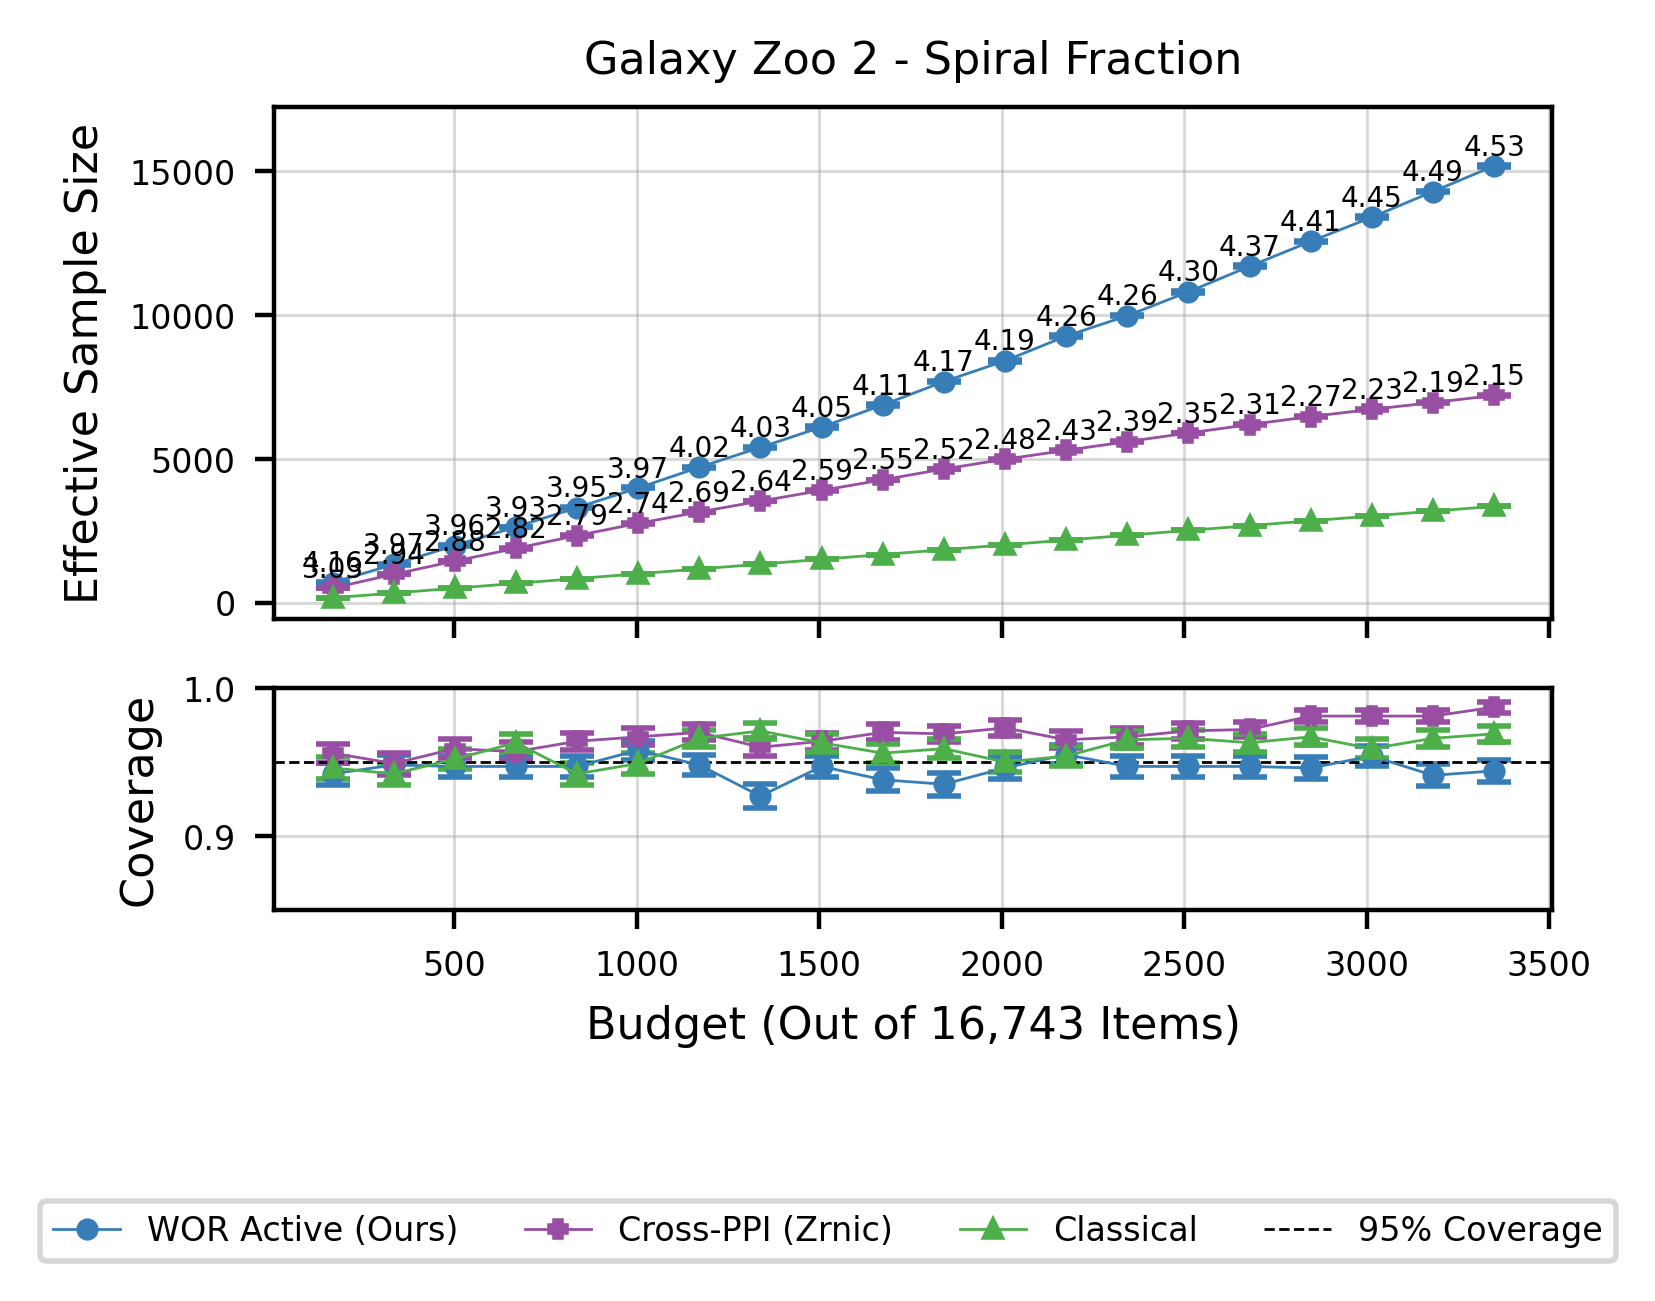

In [13]:
# Main comparison. The Active Inference line appears once run_active_inference.py has run.
method_config_main = [
    ("wor-active",       "o", colors[0], "WOR Active (Ours)",        True),
    ("active-inference", "*", colors[7], "Active Inference (Zrnic)", True),
    ("cross-ppi",        "P", colors[5], "Cross-PPI (Zrnic)",        True),
    ("classical",        "^", colors[2], "Classical",                False),
]
make_figure("ess_multiplier_vs_classical", "ess_multiplier_vs_classical_serr",
            method_config_main, legend_ncol=4)

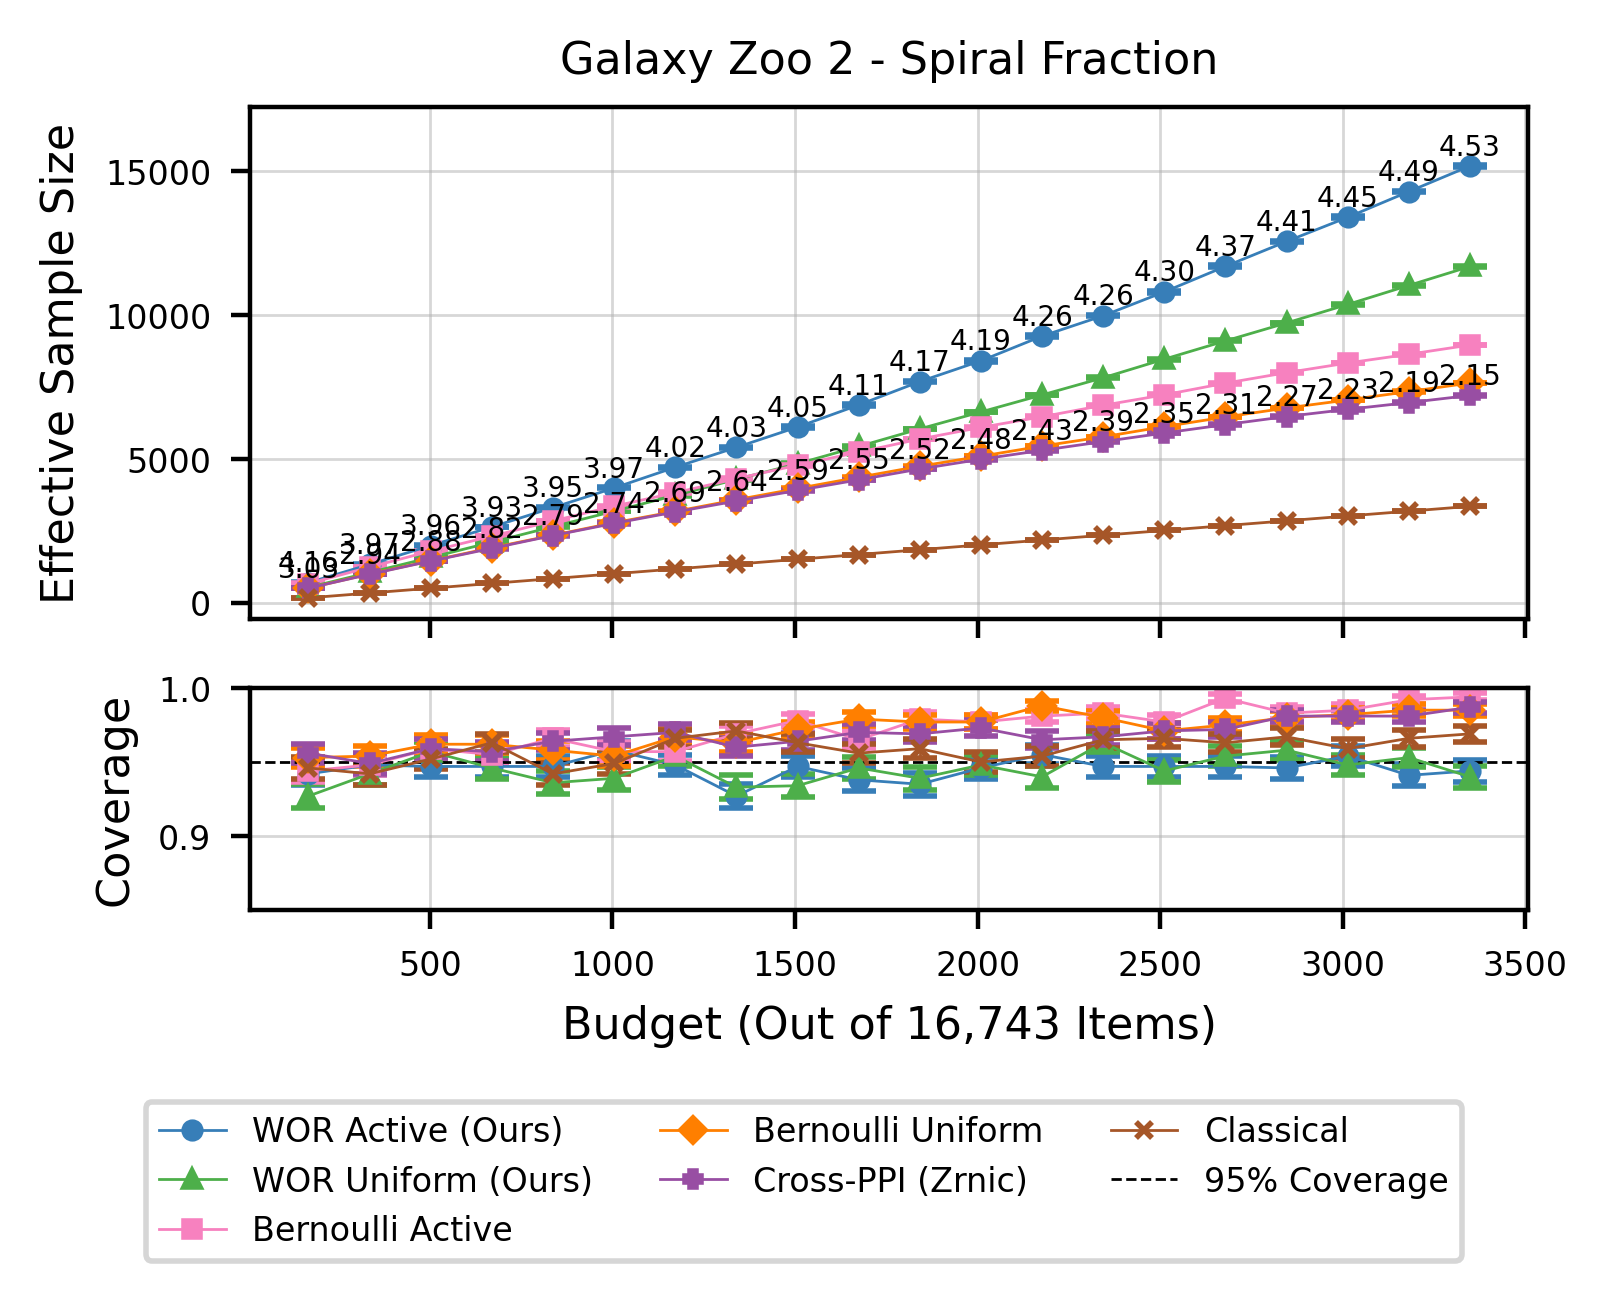

In [14]:
method_config_all = [
    ("wor-active",        "o", colors[0], "WOR Active (Ours)",        True),
    ("wor-uniform",       "^", colors[2], "WOR Uniform (Ours)",       False),
    ("bernoulli-active",  "s", colors[3], "Bernoulli Active",         False),
    ("bernoulli-uniform", "D", colors[1], "Bernoulli Uniform",        False),
    ("active-inference",  "*", colors[7], "Active Inference (Zrnic)", False),
    ("cross-ppi",         "P", colors[5], "Cross-PPI (Zrnic)",        True),
    ("classical",         "x", colors[4], "Classical",                False),
]
make_figure("ess_multiplier_vs_classical", "ess_multiplier_vs_classical_serr", method_config_all)